### Simple linear regression

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

**Load the data**

In [26]:
df =pd.read_csv("datasets/salary.csv")
df.head()

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525


**Realtionship between features and target**

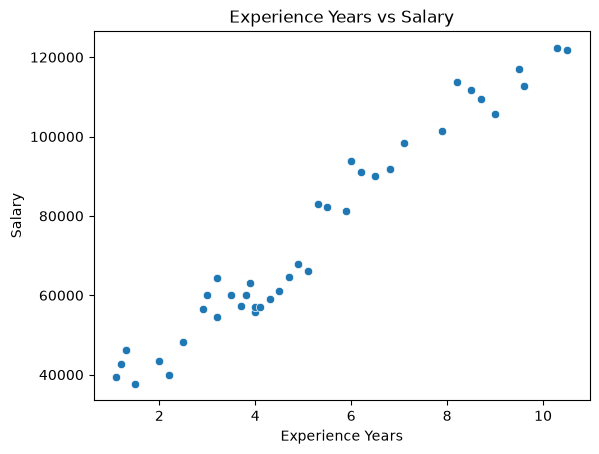

In [27]:
sns.scatterplot(x="Experience Years", y ="Salary", data=df)
plt.title("Experience Years vs Salary")
plt.show()

In [28]:
df.corr()

,Experience Years,Salary
Experience Years,1.000000,0.977692
Salary,0.977692,1.000000


**Split the data into dependent and independent features**

In [29]:
X = df[["Experience Years"]]  # independent features
y = df["Salary"]              # dependent features

**Train test split**

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test , y_train, y_test = train_test_split(X,y,
                                                     test_size=0.2,
                                                     random_state=42)
X_train.shape, X_test.shape , y_train.shape , y_test.shape

((32, 1), (8, 1), (32,), (8,))

**Standardization**

Not needed here, but I am doing it for practice.

In [31]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [32]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [33]:
X_train[:5]

array([[ 1.93892298],
       [-0.98258545],
       [ 0.25905563],
       [-0.72695347],
       [-0.50784033]])

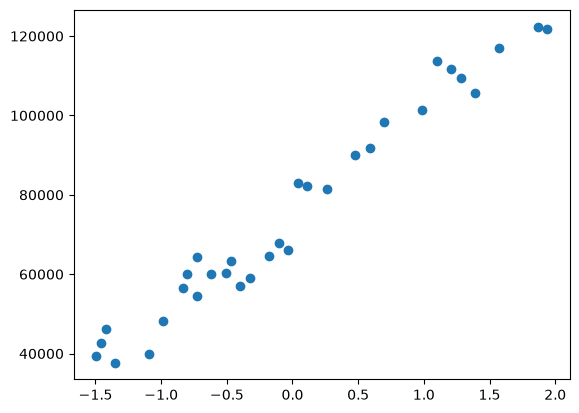

In [35]:
plt.scatter(X_train,y_train);

**train the model**

In [36]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [37]:
reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[25762.12]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.555e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[5.66]


In [40]:
print(f"slope or coefficient of weight: {reg.coef_}")
print(f"intercept: {reg.intercept_}")

slope or coefficient of weight: [25762.11977638]
intercept: 75549.8125


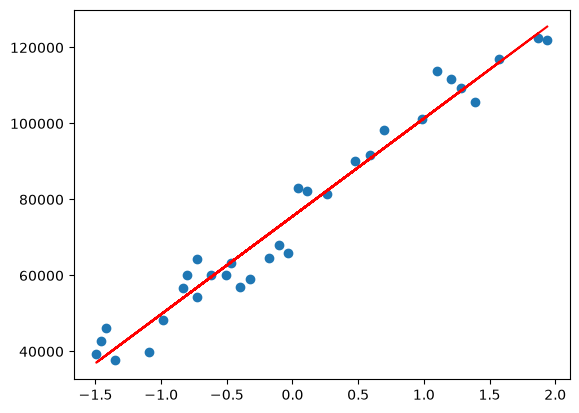

In [45]:
plt.scatter(X_train, y_train)
plt.plot(X_train , reg.predict(X_train), c='r');

**Prediction on Train Data**

1. **Prediction formula:**

   $$\hat{y}_{train} = \beta_0 + \beta_1 X_{train}$$

2. **Substituting the values:**

   $$\hat{y}_{train} = 75549.8125 + 25762.11977638(X_{train})$$

**Prediction on Test Data**

1. **Prediction formula:**

   $$\hat{y}_{test} = \beta_0 + \beta_1 X_{test}$$

2. **Substituting the values:**

   $$\hat{y}_{test} = 75549.8125 + 25762.11977638(X_{test})$$


**predication on the test data**

In [46]:
y_pred = reg.predict(X_test)
y_pred

array([ 69052.39090243,  64348.37526617,  64348.37526617,  83164.43781119,
        45532.31272116,  61525.96588442, 117033.35039221,  85046.04406569])

In [47]:
y_test

19     61111
16     56957
15     55794
26     93940
4      43525
12     57189
37    112635
27     91000
Name: Salary, dtype: int64

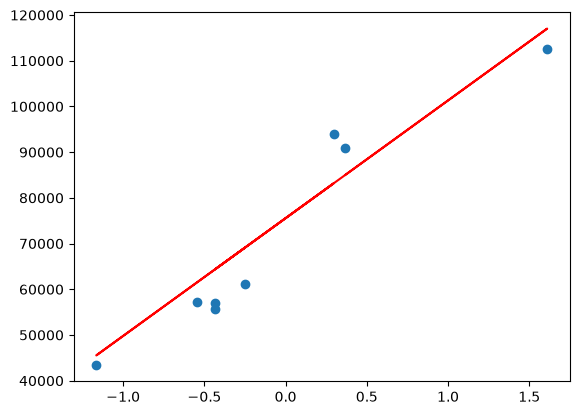

In [51]:
plt.scatter(X_test, y_test)
plt.plot(X_test,y_pred, c="r");


**Performance Metrics**

In [52]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
MSE = mean_squared_error(y_test,y_pred)
MAE = mean_absolute_error(y_test,y_pred)
RMSE = np.sqrt(MSE)
score = r2_score(y_test, y_pred)

In [54]:
print(f"MSE: {MSE}")
print(f"MAE: {MAE}")
print(f"RMSE: {RMSE}")

MSE: 48077731.1691936
MAE: 6419.911069460599
RMSE: 6933.810724932835


In [55]:
print(f"r2_score: {score}")

r2_score: 0.9068577573647872


**Adjusted r squared**

In [59]:
n = X_test.shape[0]
k = X_test.shape[1]

adjusted_rSquare = 1 - ((1 - score) * (n - 1)) / (n - k - 1)

adjusted_rSquare

0.8913340502589184

**Predication for new data**

In [70]:
weight = 4.5
scaled_weight = scaler.transform([[weight]])
scaled_weight[0]

c:\Users\avina\OneDrive\Desktop\ml-playground\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([-0.25220835])

In [72]:
reg.predict(scaled_weight)

array([69052.39090243])

**Assumptions**

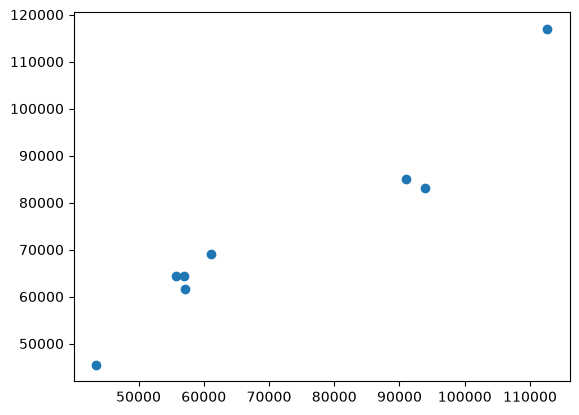

In [74]:
# plot a scatter plot for test predication
plt.scatter(y_test, y_pred);

In [75]:
# Residuals
residuals = y_test - y_pred
residuals

19    -7941.390902
16    -7391.375266
15    -8554.375266
26    10775.562189
4     -2007.312721
12    -4336.965884
37    -4398.350392
27     5953.955934
Name: Salary, dtype: float64

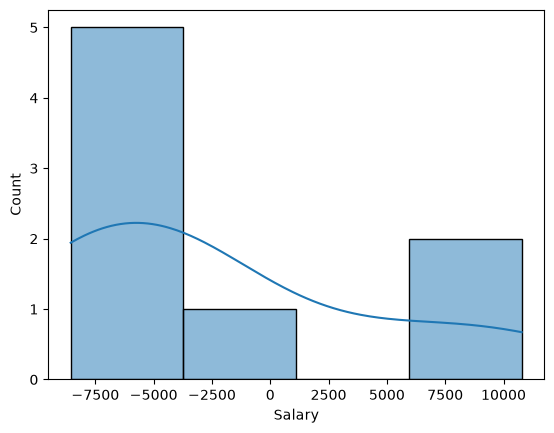

In [77]:
# plot the residuals
sns.histplot(residuals , kde=True);

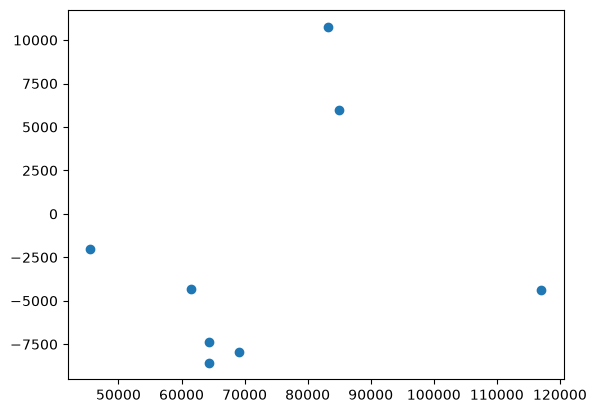

In [79]:
# scatterplot with rescpect to predication and residuals
# it should be uniform distribution
plt.scatter(y_pred, residuals);